# Agent trajectories

Note: This notebook only uses data from the agents trained with seed 17. It does not include runs with other seeds.

In [155]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [156]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [157]:
data_folder = '/Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs'
solo_files = identify_filepaths.get_relative_paths('Solo', data_folder)

df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

IntProgress(value=0, max=43)

filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260416_1/2026-04-29_13-30-52_M18_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_1/2026-04-29_11-42-49_M19_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_2/2026-04-29_08-18-54_M20_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_3/2026-04-29_06-54-23_M21_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260417_4/2026-04-28_19-57-43_M22_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/data/agents_seed_17_full_logs/260418_1/2026-04-28_18-35-32_M23_Solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/Documents/swc/agents/da

In [159]:
dropped_trials = 1

In [160]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 539
First trial end event found at index: 545
First trial end event found at index: 539
First trial end event found at index: 555
First trial end event found at index: 556
First trial end event found at index: 557
First trial end event found at index: 553
First trial end event found at index: 547
First trial end event found at index: 576
First trial end event found at index: 547
First trial end event found at index: 518
First trial end event found at index: 519
First trial end event found at index: 545
First trial end event found at index: 553
First trial end event found at index: 578
First trial end event found at index: 546
First trial end event found at index: 533
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 538
First trial end event found at index: 538
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at ind

In [161]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

In [162]:
len(trial_lists)

43

### Parameter value extraction

In [163]:
import agent_analysis.functions.preprocessing as prep

In [164]:
folders, step_penalties = prep.extract_step_penalties(data_folder, yaml_filename=None)

## Session trajectories

In [165]:
import agent_analysis.functions.plotting as plot

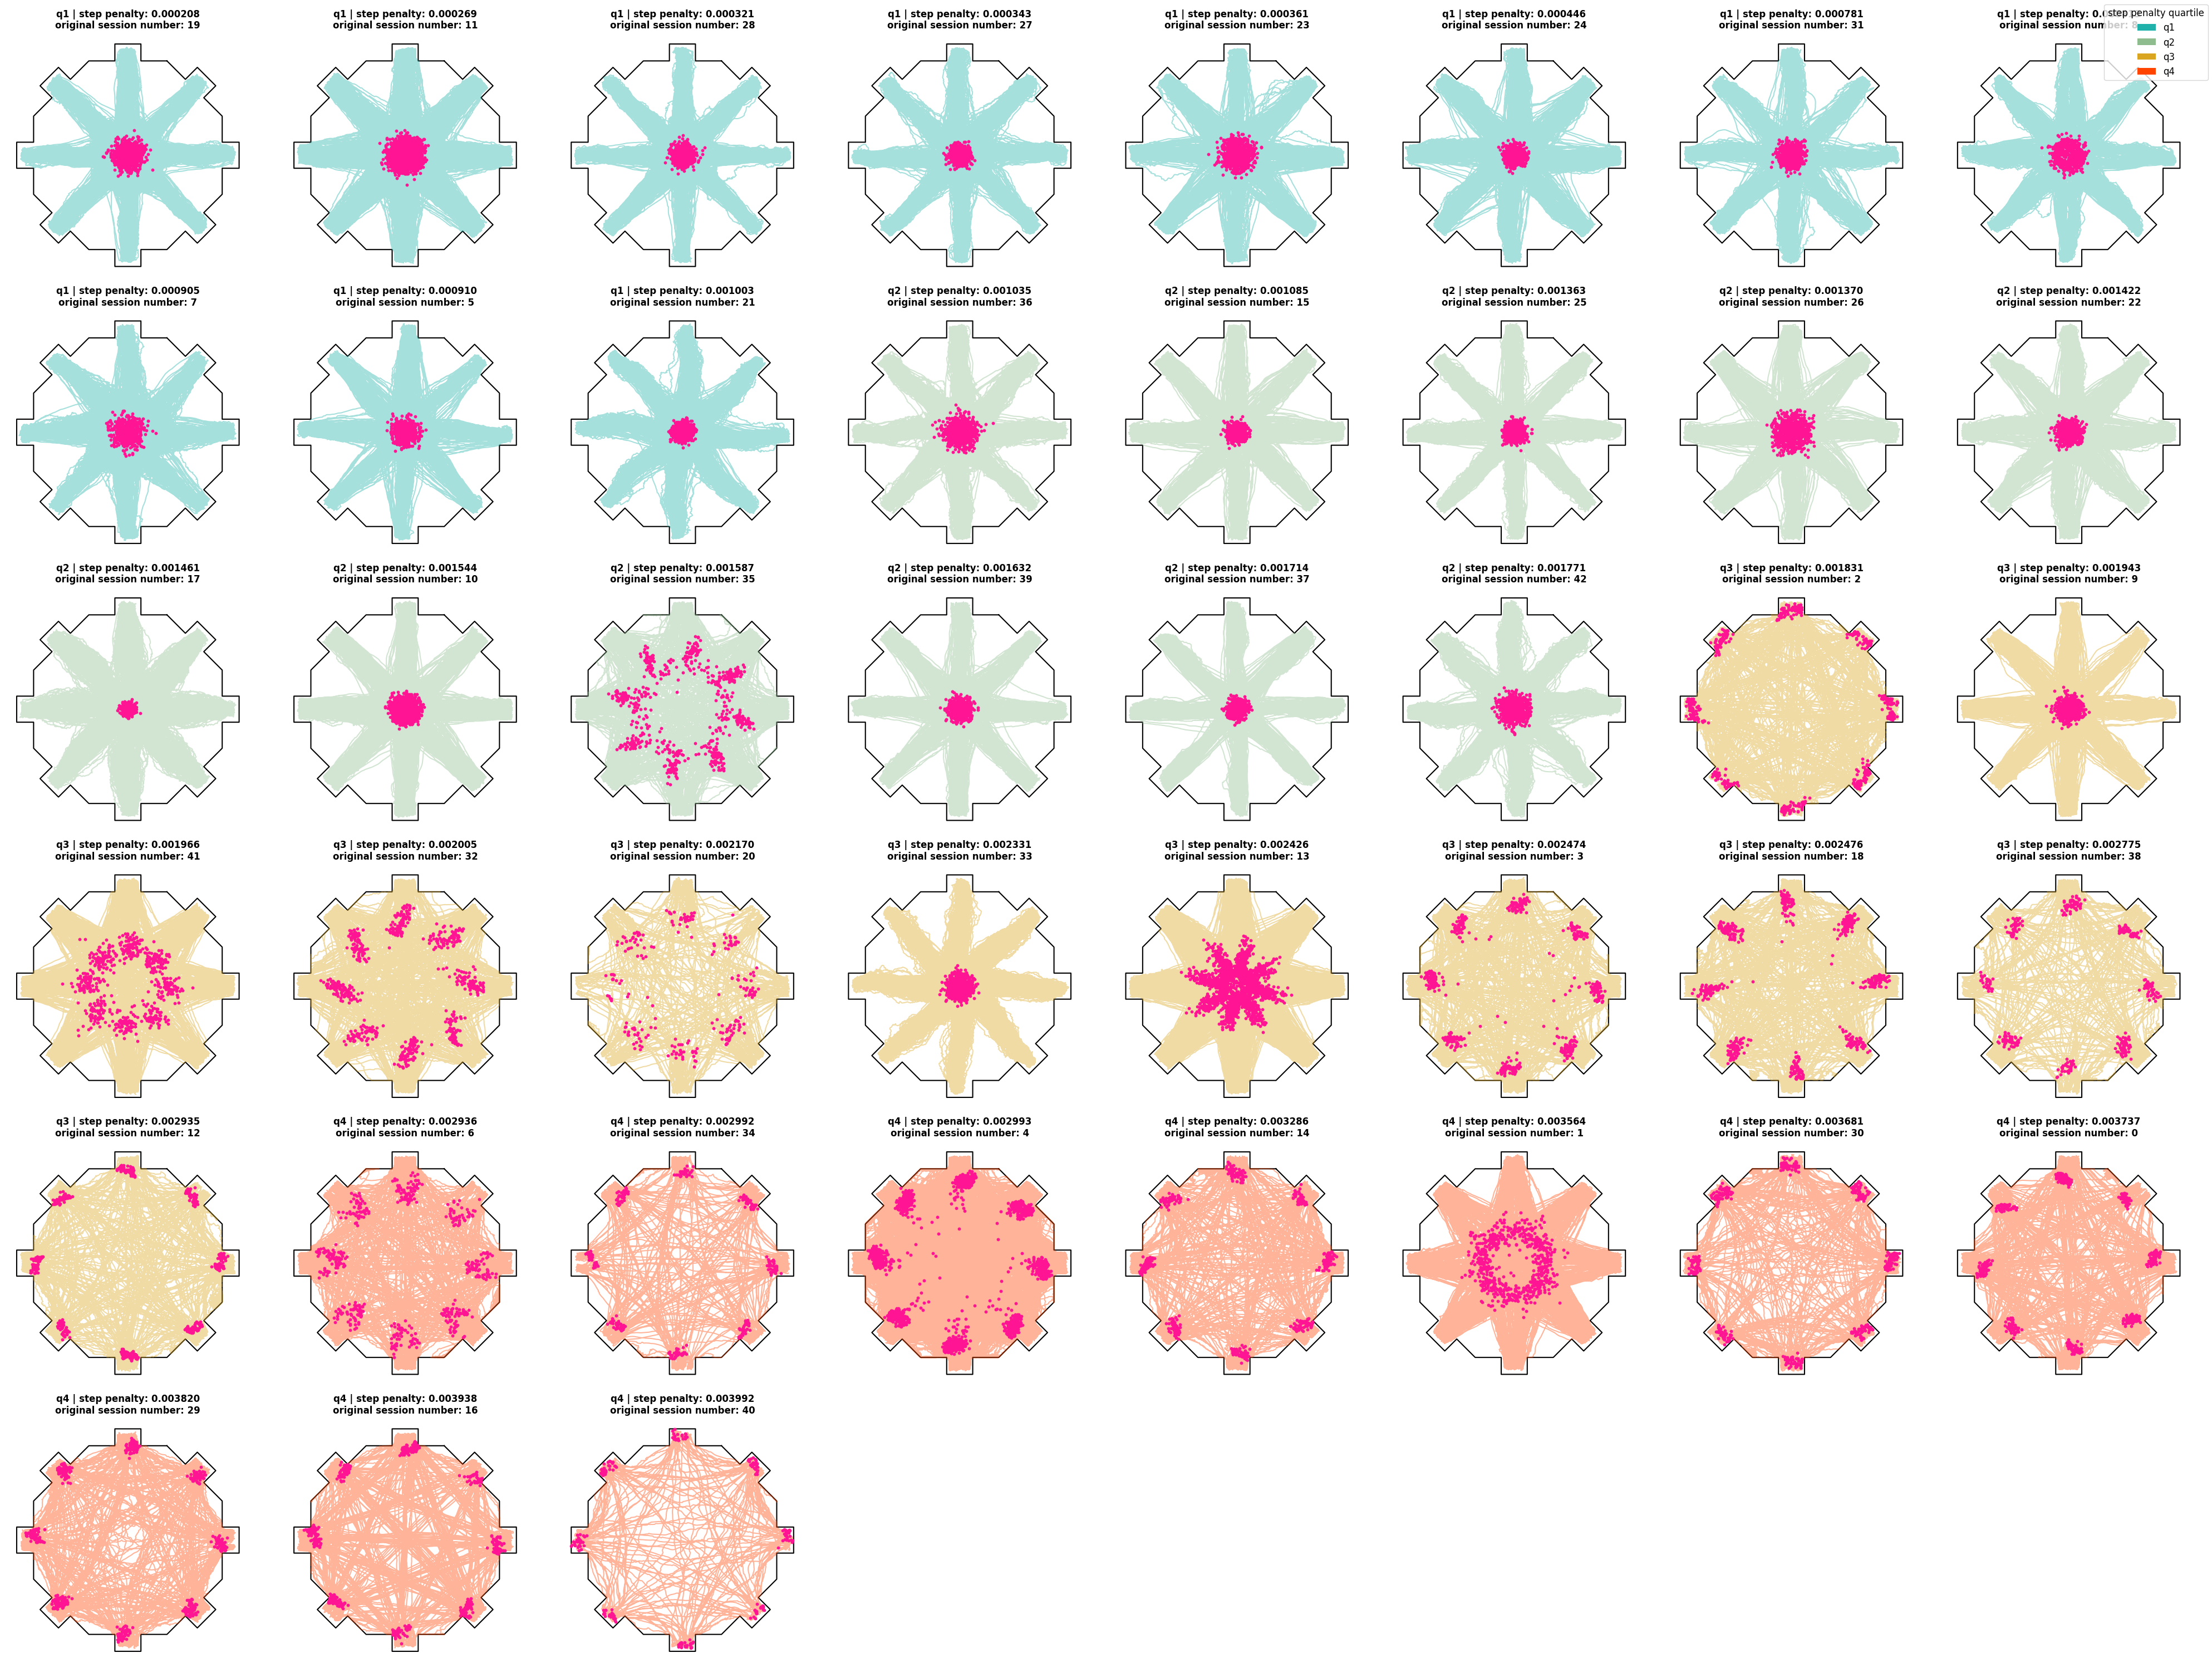

In [167]:
plot.plot_sorted_session_trajectories(dfs_cropped, step_penalties, color_by_quartile=True)

# Central agent example slice onset position heatmap

In [601]:
def collect_slice_onset_radii(trial_lists, player_id=0):
    """Collect radial distances at slice onset across trial lists."""

    radii = []

    for trial_list in trial_lists:
        for trial_index in range(1, len(trial_list)):
            pos = opponent_visibility.get_player_position_slice_onset(
                player_id=player_id,
                trial=None,
                trial_list=trial_list,
                trial_index=trial_index
            )

            if pos is None:
                continue

            x_val, y_val = pos
            r = np.sqrt(x_val**2 + y_val**2)
            radii.append(r)

    return np.asarray(radii)

In [602]:
num_rings = 10
arena_radius = 19.74449542008289

radial_bins = np.linspace(0, arena_radius, num_rings + 1)

In [603]:
from matplotlib.patches import Polygon
import matplotlib as mpl
from matplotlib import cm
import matplotlib.pyplot as plt

In [604]:
def plot_slice_onset_ring_counts(
    ring_counts,
    radial_bins,
    cmap_name="inferno",
    show_counts=True,
    title="Slice-onset position counts"
):
    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(
        vmin=0,
        vmax=np.nanmax(ring_counts)
    )

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor="none",
        edgecolor="none",
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        count = ring_counts[i]

        patch = Polygon(
            vertices,
            facecolor=cmap(norm(count)),
            edgecolor="none",
            linewidth=0.001,
            antialiased=True
        )

        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        if show_counts:
            ax.text(
                0,
                r_mid,
                str(int(count)),
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                fontweight="bold"
            )

    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor="black",
        facecolor="none",
        lw=2
    )
    ax.add_patch(octagon_patch)

    ax.set_title(title, fontsize=18)
    ax.set_xlim([-arena_radius, arena_radius])
    ax.set_ylim([-arena_radius, arena_radius])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.75)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    #cbar.set_ticks(np.arange(0, 3501, 1000))
    cbar.set_label("slice-onset count", fontsize=20)

    return fig, ax

In [608]:
solo_example = [trial_lists_solo[28]]

In [609]:
radii = collect_slice_onset_radii(
    solo_example,
    player_id=0
)

ring_counts, _ = np.histogram(radii, bins=radial_bins)

print(ring_counts)

[576  88   1   0   0   0   0   0   0   0]


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/2306990636.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>, <Axes: >)

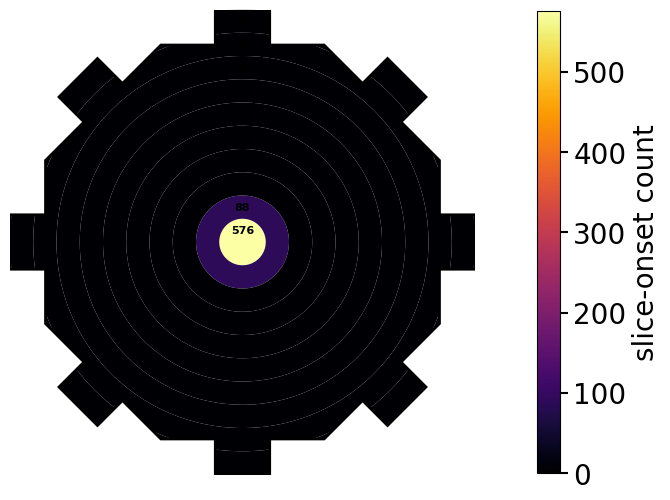

In [610]:
plot_slice_onset_ring_counts(
    ring_counts,
    radial_bins,
    title=""
)

In [611]:
ring_proportions_solo = ring_counts / np.sum(ring_counts)

In [612]:
ring_proportions_solo

array([0.86616541, 0.13233083, 0.00150376, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [616]:
def plot_slice_onset_ring_proportions(
    ring_proportions,
    radial_bins,
    cmap_name="inferno",
    show_values=True,
    title="Slice-onset position proportions"
):
    octagon_vertex_coordinates = plot_octagon.return_octagon_path_points()

    fig, ax = plt.subplots(figsize=(8, 8))

    cmap = cm.get_cmap(cmap_name)
    norm = mpl.colors.Normalize(vmin=0, vmax=np.nanmax(ring_proportions))

    octagon_clip = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        facecolor="none",
        edgecolor="none",
        transform=ax.transData
    )

    for i in range(len(radial_bins) - 1):
        r_inner = radial_bins[i]
        r_outer = radial_bins[i + 1]
        r_mid = (r_inner + r_outer) / 2

        theta = np.linspace(0, 2 * np.pi, 500)

        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)

        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])

        vertices = np.column_stack([
            np.concatenate([x_outer, x_inner]),
            np.concatenate([y_outer, y_inner])
        ])

        prop = ring_proportions[i]

        patch = Polygon(
            vertices,
            facecolor=cmap(norm(prop)),
            edgecolor="none",
            linewidth=0,
            antialiased=True
        )
        patch.set_clip_path(octagon_clip)
        ax.add_patch(patch)

        if show_values:
            ax.text(
                0,
                r_mid,
                f"{prop:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black",
                fontweight="bold"
            )

    # optional ring outlines without seam
    for r in radial_bins[1:-1]:
        circle = plt.Circle(
            (0, 0),
            r,
            edgecolor="black",
            facecolor="none",
            linewidth=0.4
        )
        circle.set_clip_path(octagon_clip)
        ax.add_patch(circle)

    octagon_patch = Polygon(
        octagon_vertex_coordinates,
        closed=True,
        edgecolor="black",
        facecolor="none",
        lw=2
    )
    ax.add_patch(octagon_patch)

    ax.set_title(title, fontsize=18)
    ax.set_xlim([-25, 25])
    ax.set_ylim([-25, 25])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.005, shrink=0.7)
    cbar.ax.tick_params(labelsize=20, length=6, width=1.5)
    #cbar.set_ticks(np.arange(0, 0.16, 0.05))
    cbar.set_label("proportion of slice onset positions", fontsize=20)

    return fig, ax

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/3837852954.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


(<Figure size 800x800 with 2 Axes>, <Axes: >)

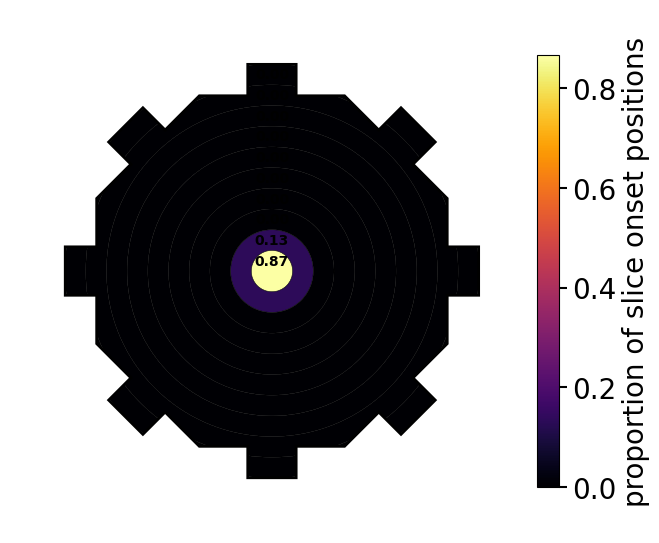

In [617]:
plot_slice_onset_ring_proportions(
    ring_proportions_solo,
    radial_bins,
    title=""
)

# Centrality by step penalty value

In [254]:
from analysis import opponent_visibility

Get slice onset positions for each session for each trial

In [255]:
slice_onset_positions_dict = {}
for j, trial_list in enumerate(trial_lists):
    pos_list = []
    for i in range(len(trial_list)):
        if i == 0:
            continue
        slice_onset_positions = (opponent_visibility.get_player_position_slice_onset(player_id=0, trial=None, trial_list=trial_list, trial_index=i))
        pos_list.append(slice_onset_positions)
    slice_onset_positions_dict[j] = pos_list

Find the arena radius through the data

In [256]:
all_positions = np.array([
    pos for pos_list in slice_onset_positions_dict.values()
    for pos in pos_list
    if pos is not None
])

In [257]:
arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

In [258]:
arena_radius

np.float64(19.74449542008289)

In [259]:
centrality_dict = {}
mean_centrality_dict = {}
for j, pos_list in slice_onset_positions_dict.items():
    centrality_dict[j] = []
    for pos in pos_list:
        if pos is None:
            centrality_dict[j].append(np.nan)
            continue
        dist = np.linalg.norm(pos)
        centrality = 1 - (dist / arena_radius) if arena_radius > 0 else 1.0
        centrality_dict[j].append(centrality)
    mean_centrality_dict[j] = np.nanmean(centrality_dict[j])

In [260]:
mean_centrality_dict[0]

np.float64(0.23560962399655708)

In [261]:
centrality_dict[0][0]

np.float64(0.22526686443514354)

In [262]:
# collect average centrality for each session, sorted by step penalty
mean_centrality_list = []
std_centrality_list = []
sem_centrality_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_centrality_dict.keys()), key=lambda x: x[0]):
    #if session_id == 31:
        #continue
    
    values = np.array(centrality_dict[session_id], dtype=float)
    mean_centrality_list.append(np.mean(values))
    std_centrality_list.append(np.std(values))
    sem_centrality_list.append(np.nanstd(values) / np.sqrt(np.sum(~np.isnan(values))))
    sorted_penalties.append(penalty)

with SEM

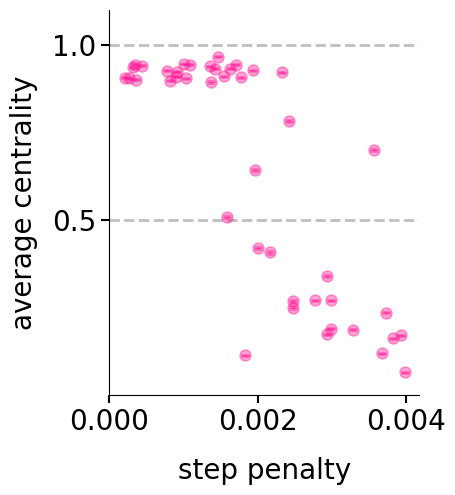

In [265]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    mean_centrality_list,
    yerr=sem_centrality_list,
    fmt='o',
    alpha=0.4,
    color="deeppink",
    markersize=8,

    ecolor='deeppink',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("step penalty", fontsize=20, labelpad=15)
plt.ylabel("average centrality", fontsize=20, labelpad=10)

plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.xticks(np.arange(0, 0.0045, 0.002), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.show()

### looks nonlinear (slope changes) but monotonic (same direction)

In [266]:
x = np.array(sorted_penalties)
y = np.array(mean_centrality_list)

Fit simple linear model

In [267]:
from sklearn.linear_model import LinearRegression

In [268]:
lin_model = LinearRegression()
lin_model.fit(x.reshape(-1, 1), y)

y_pred_lin = lin_model.predict(x.reshape(-1, 1))

# residual sum of squares
rss_lin = np.sum((y - y_pred_lin)**2)

# R^2
r2_lin = lin_model.score(x.reshape(-1,1), y)

print("Linear R²:", r2_lin)

Linear R²: 0.6624551832480203


Fit piecewise regression

In [269]:
import pwlf

In [270]:
pw_model = pwlf.PiecewiseLinFit(x, y)

# 2 segments → 1 breakpoint
breaks = pw_model.fit(2)

breakpoint = breaks[1]

# predictions
y_pred_pw = pw_model.predict(x)

rss_pw = np.sum((y - y_pred_pw)**2)

# pseudo R²
r2_pw = 1 - (rss_pw / np.sum((y - np.mean(y))**2))

print("Breakpoint:", breakpoint)
print("Piecewise R²:", r2_pw)

Breakpoint: 0.0010851711715390317
Piecewise R²: 0.6931603611728453


Compare models

In [271]:
n = len(x)

def compute_aic(rss, k, n):
    return n * np.log(rss / n) + 2 * k

aic_lin = compute_aic(rss_lin, k=2, n=n)
aic_pw  = compute_aic(rss_pw,  k=4, n=n)

print("AIC linear:", aic_lin)
print("AIC piecewise:", aic_pw)

AIC linear: -137.12973531429193
AIC piecewise: -137.23077559804804


slopes

In [272]:
slopes = pw_model.slopes

print("Slope before breakpoint:", slopes[0])
print("Slope after breakpoint:", slopes[1])

Slope before breakpoint: 5.358599090184018
Slope after breakpoint: -292.5508017258738


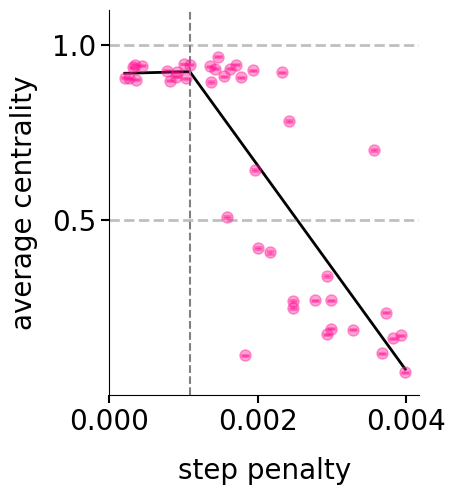

In [274]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    mean_centrality_list,
    yerr=sem_centrality_list,
    fmt='o',
    alpha=0.4,
    color="deeppink",
    markersize=8,

    ecolor='deeppink',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

# piecewise fit line
x_sorted = np.sort(x)
y_pw_sorted = pw_model.predict(x_sorted)

plt.plot(x_sorted, y_pw_sorted, color='black', linewidth=2)

# breakpoint line
plt.axvline(breakpoint, linestyle='--', color='gray')

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("step penalty", fontsize=20, labelpad=15)
plt.ylabel("average centrality", fontsize=20, labelpad=10)

plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.xticks(np.arange(0, 0.0045, 0.002), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.show()

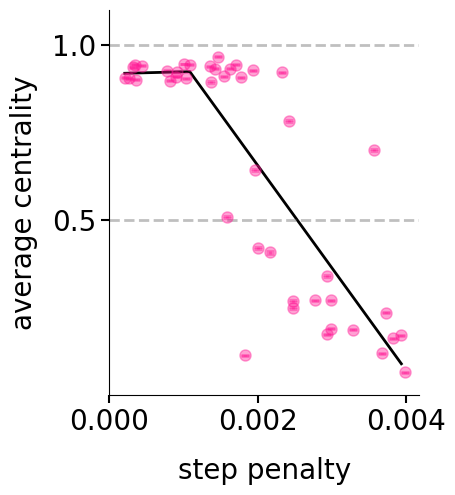

In [275]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(4, 5))

# --- static elements ---
ax.errorbar(
    sorted_penalties,
    mean_centrality_list,
    yerr=sem_centrality_list,
    fmt='o',
    alpha=0.4,
    color="deeppink",
    markersize=8,
    ecolor='deeppink',
    elinewidth=2,
    capsize=3,
    capthick=2,
    linestyle='none'
)

# piecewise fit data
x_sorted = np.sort(x)
y_pw_sorted = pw_model.predict(x_sorted)

# empty line (this will be animated)
line, = ax.plot([], [], color='black', linewidth=2)

# static reference lines
#vline = ax.axvline(breakpoint, linestyle='--', color='gray', alpha=0)
plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("step penalty", fontsize=20, labelpad=15)
plt.ylabel("average centrality", fontsize=20, labelpad=10)

plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)
plt.xticks(np.arange(0, 0.0045, 0.002), fontsize=20)

sns.despine(top=True, right=True)
ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

# --- animation function ---
frames = len(x_sorted) + 30  # extra frames at end

def update(frame):
    idx = min(frame, len(x_sorted))
    line.set_data(x_sorted[:idx], y_pw_sorted[:idx])
    return line,

# create animation
anim = FuncAnimation(
    fig,
    update,
    frames=len(x_sorted),
    interval=200,
    blit=True
)

anim.save(
    "centrality_fit.gif",
    writer="pillow",
    fps=30
)

plt.show()

with SD

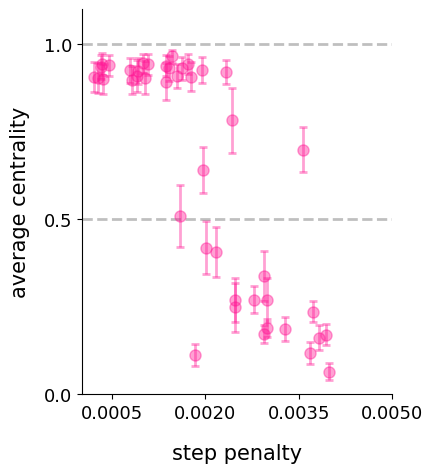

In [276]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    mean_centrality_list,
    yerr=std_centrality_list,
    fmt='o',
    alpha=0.4,
    color="deeppink",
    markersize=8,

    ecolor='deeppink',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("average centrality", fontsize=15, labelpad=10)

plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

without either

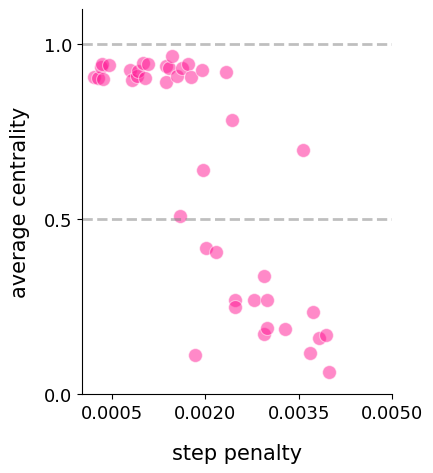

In [277]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=sorted_penalties, y=mean_centrality_list, marker='o', alpha=0.5, color="deeppink", s=100)
plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("average centrality", fontsize=15, labelpad=10)
plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
#ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

### box plots

In [237]:
def add_sig_bar(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c='black')

    if p < 0.001:
        text = '***'
    elif p < 0.01:
        text = '**'
    elif p < 0.05:
        text = '*'
    else:
        text = 'n.s.'

    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

def add_sig(ax, x1, x2, y, h, p):
    #ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.5, c='black')

    if p < 0.001:
        text = '***'
    elif p < 0.01:
        text = '**'
    elif p < 0.05:
        text = '*'
    else:
        text = 'n.s.'

    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

In [565]:
penalties = np.array(sorted_penalties)
means = np.array(mean_centrality_list)

# Sort indices by penalty
sorted_idx = np.argsort(penalties)

# Split into 4 equal-sized groups
quartile_indices = np.array_split(sorted_idx, 4)

q1_group = means[quartile_indices[0]]
q2_group = means[quartile_indices[1]]
q3_group = means[quartile_indices[2]]
q4_group = means[quartile_indices[3]]

In [279]:
from scipy.stats import kruskal, mannwhitneyu
import itertools

In [566]:
# overall test (4 groups)
stat, p = kruskal(q1_group, q2_group, q3_group, q4_group)
print("Kruskal-Wallis p =", p)

# pairwise comparisons
groups = {
    "q1": q1_group,
    "q2": q2_group,
    "q3": q3_group,
    "q4": q4_group
}

pairwise_p = {}

for (name1, g1), (name2, g2) in itertools.combinations(groups.items(), 2):
    p_val = mannwhitneyu(g1, g2, alternative='two-sided').pvalue
    pairwise_p[f"{name1} vs {name2}"] = p_val

# print results
for k, v in pairwise_p.items():
    print(f"{k}: p = {v}")

Kruskal-Wallis p = 5.93440726533289e-06
q1 vs q2: p = 0.8955142436987509
q1 vs q3: p = 0.0016220041892740272
q1 vs q4: p = 0.0001241544606016335
q2 vs q3: p = 0.0016220041892740272
q2 vs q4: p = 0.0001649853008759357
q3 vs q4: p = 0.04475929457557227


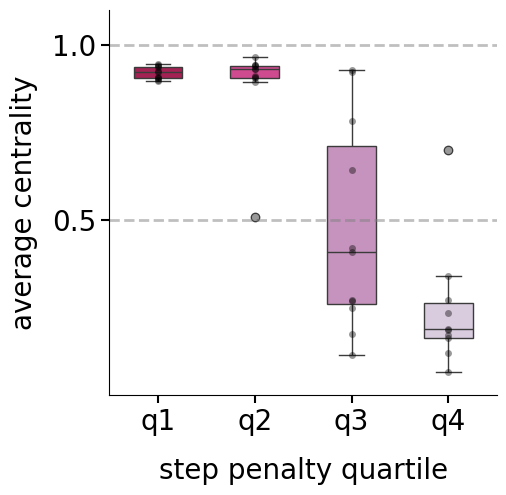

In [568]:
data = [q1_group, q2_group, q3_group, q4_group]

palette = sns.color_palette("PuRd_r", 4)

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)
plt.axhline(1.0, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("step penalty quartile", fontsize=20, labelpad=15)
plt.ylabel("average centrality", fontsize=20, labelpad=10)

plt.ylim([0.7, 1.1])
plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(means)
h = y_max * 0.05

# using pairwise_p dictionary from previous code
#add_sig_bar(ax, 0, 1, y_max + h, h, pairwise_p["q1 vs q2"])
#add_sig_bar(ax, 1, 2, y_max + h,   h, pairwise_p["q2 vs q3"])
#add_sig_bar(ax, 2, 3, y_max + h,   h, pairwise_p["q3 vs q4"])

# optional wider comparisons
#add_sig_bar(ax, 0, 2, y_max + 7*h,   h, pairwise_p["q1 vs q3"])
#add_sig_bar(ax, 1, 3, y_max + 9*h,   h, pairwise_p["q2 vs q4"])
#add_sig_bar(ax, 0, 3, y_max + 3*h,  h, pairwise_p["q1 vs q4"])

plt.show()

# Trajectory efficiency by step penalty

In [569]:
from analysis import trajectory_efficiency

In [570]:
player_index = 0

In [571]:
mean_efficiency_ratios_dict = {}
efficiency_ratios_dict = {}
direct_distances_dict = {}
actual_distances_dict = {}

for session_id, trial_list in enumerate(trial_lists):
    #if session_id == 36:
        #continue

    print(session_id)
    print(len(trial_list))

    direct_dist = trajectory_efficiency.player_direct_distance_session(trial_list, player_index)
    actual_dist = trajectory_efficiency.player_actual_distance_session(trial_list, player_index)

    efficiency_ratios = direct_dist / actual_dist
    mean_efficiency_ratio = np.nanmean(direct_dist / actual_dist)
    print(f"Mean efficiency ratio: {mean_efficiency_ratio}")

    mean_efficiency_ratios_dict[session_id] = mean_efficiency_ratio
    efficiency_ratios_dict[session_id] = efficiency_ratios
    direct_distances_dict[session_id] = direct_dist
    actual_distances_dict[session_id] = actual_dist

0
467
Mean efficiency ratio: 0.8673894292417461
1
666
Mean efficiency ratio: 0.9368011399355104
2
588


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/1838265312.py:16: RuntimeWarning: invalid value encountered in divide
  efficiency_ratios = direct_dist / actual_dist
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/1838265312.py:17: RuntimeWarning: invalid value encountered in divide
  mean_efficiency_ratio = np.nanmean(direct_dist / actual_dist)


Mean efficiency ratio: 0.8776869298850154
3
533
Mean efficiency ratio: 0.8335198846263301
4
1929
Mean efficiency ratio: 0.8377040920742092
5
568
Mean efficiency ratio: 0.9323659579842511
6
507
Mean efficiency ratio: 0.9378792428190009
7
521
Mean efficiency ratio: 0.928958651029744
8
511
Mean efficiency ratio: 0.8838050296425715
9
622
Mean efficiency ratio: 0.9148169813049642
10
944
Mean efficiency ratio: 0.9480939733166324
11
1998
Mean efficiency ratio: 0.8836721151177379
12
500
Mean efficiency ratio: 0.8340685300362213
13
1800
Mean efficiency ratio: 0.9241288334192508
14
480
Mean efficiency ratio: 0.8673265274363577
15
517
Mean efficiency ratio: 0.9414897007325809
16
501
Mean efficiency ratio: 0.9275671279189711
17
661
Mean efficiency ratio: 0.9483580479205903
18
562
Mean efficiency ratio: 0.9020739336259684
19
667
Mean efficiency ratio: 0.9018524543130144
20
242
Mean efficiency ratio: 0.9100603523320889
21
668
Mean efficiency ratio: 0.9113931523281715
22
675
Mean efficiency ratio: 0.

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/1838265312.py:16: RuntimeWarning: invalid value encountered in divide
  efficiency_ratios = direct_dist / actual_dist
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/1838265312.py:17: RuntimeWarning: invalid value encountered in divide
  mean_efficiency_ratio = np.nanmean(direct_dist / actual_dist)


Mean efficiency ratio: 0.8632909923542159
31
658
Mean efficiency ratio: 0.930263567266518
32
628
Mean efficiency ratio: 0.9201532214552773
33
668
Mean efficiency ratio: 0.9364498441636536
34
267
Mean efficiency ratio: 0.8807219855370334
35
635
Mean efficiency ratio: 0.9340384662770581
36
663
Mean efficiency ratio: 0.897831791531448
37
539
Mean efficiency ratio: 0.9557721869405692
38
342
Mean efficiency ratio: 0.8856576826355326
39
539
Mean efficiency ratio: 0.9330485715680725
40
215
Mean efficiency ratio: 0.8752213833517384
41
634


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/1838265312.py:16: RuntimeWarning: invalid value encountered in divide
  efficiency_ratios = direct_dist / actual_dist
/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/1838265312.py:17: RuntimeWarning: invalid value encountered in divide
  mean_efficiency_ratio = np.nanmean(direct_dist / actual_dist)


Mean efficiency ratio: 0.9397126798471364
42
653
Mean efficiency ratio: 0.8892045811622492


In [572]:
# collect average trajectory efficiency for each session, sorted by step penalty
efficiency_ratios = []
direct_distances = []
actual_distances = []
std_efficiency_list = []
sem_efficiency_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, efficiency_ratios_dict.keys()), key=lambda x: x[0]):
    #if session_id == 36:
        #continue

    values = np.array(efficiency_ratios_dict[session_id], dtype=float)
    dd = np.array(direct_distances_dict[session_id], dtype=float)
    ad = np.array(actual_distances_dict[session_id], dtype=float)

    efficiency_ratios.append(np.mean(values))
    std_efficiency_list.append(np.std(values))
    sem_efficiency_list.append(np.nanstd(values) / np.sqrt(np.sum(~np.isnan(values))))
    sorted_penalties.append(penalty)

without outliers

In [295]:
def remove_outliers_iqr(values):
    values = np.array(values, dtype=float)
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return values[(values >= lower) & (values <= upper)]

In [ ]:
efficiency_ratios = []
std_efficiency_list = []
sem_efficiency_list = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, efficiency_ratios_dict.keys()), key=lambda x: x[0]):
    #if session_id == 36:
        #continue

    values = np.array(efficiency_ratios_dict[session_id], dtype=float)

    # remove NaNs first
    values = values[~np.isnan(values)]

    # remove outliers
    values = remove_outliers_iqr(values)

    if len(values) == 0:
        continue  # skip if nothing left

    efficiency_ratios.append(np.mean(values))
    std_efficiency_list.append(np.std(values))
    sem_efficiency_list.append(np.std(values) / np.sqrt(len(values)))
    sorted_penalties.append(penalty)

with SD

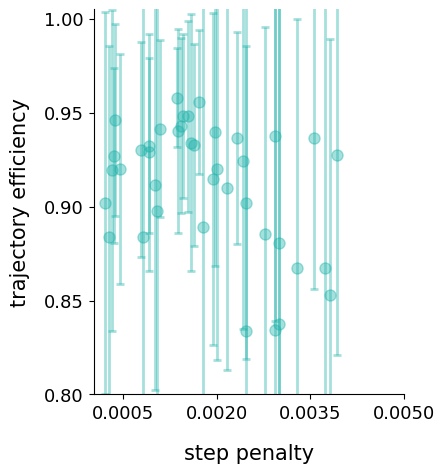

In [296]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    efficiency_ratios,
    yerr=std_efficiency_list,
    fmt='o',
    alpha=0.4,
    color="lightseagreen",
    markersize=8,

    ecolor='lightseagreen',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("trajectory efficiency", fontsize=15, labelpad=10)
plt.ylim([0.8, 1.005])
plt.yticks(np.arange(0.8, 1.005, 0.05), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

with SEM

without SD

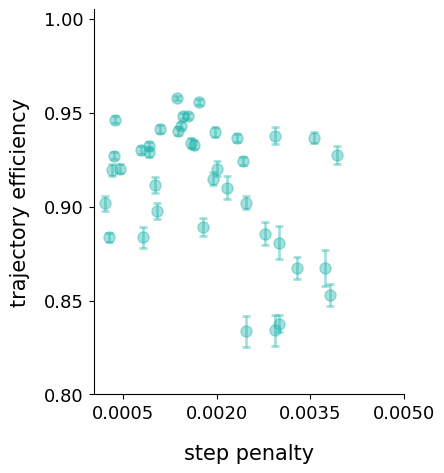

In [298]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    efficiency_ratios,
    yerr=sem_efficiency_list,
    fmt='o',
    alpha=0.4,
    color="lightseagreen",
    markersize=8,

    ecolor='lightseagreen',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("trajectory efficiency", fontsize=15, labelpad=10)
plt.ylim([0.8, 1.005])
plt.yticks(np.arange(0.8, 1.005, 0.05), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

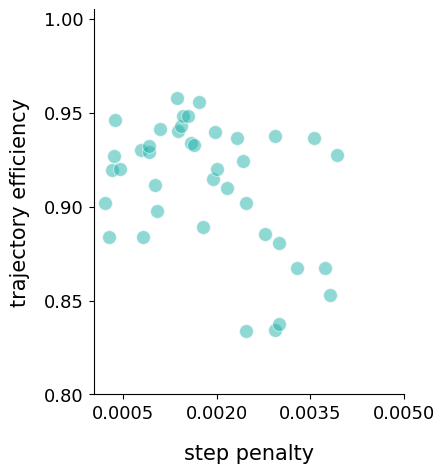

In [299]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=sorted_penalties, y=efficiency_ratios, marker='o', alpha=0.5, color="lightseagreen", s=100)
plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("trajectory efficiency", fontsize=15, labelpad=10)
plt.ylim([0.8, 1.005])
plt.yticks(np.arange(0.8, 1.005, 0.05), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
#ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

In [529]:
penalties = np.array(sorted_penalties)
means = np.array(efficiency_ratios)

# Sort indices by penalty
sorted_idx = np.argsort(penalties)

# Split into 4 equal-sized groups
quartile_indices = np.array_split(sorted_idx, 4)

q1_group = means[quartile_indices[0]]
q2_group = means[quartile_indices[1]]
q3_group = means[quartile_indices[2]]
q4_group = means[quartile_indices[3]]

In [530]:
# overall test (4 groups)
stat, p = kruskal(q1_group, q2_group, q3_group, q4_group)
print("Kruskal-Wallis p =", p)

# pairwise comparisons
groups = {
    "q1": q1_group,
    "q2": q2_group,
    "q3": q3_group,
    "q4": q4_group
}

pairwise_p = {}

for (name1, g1), (name2, g2) in itertools.combinations(groups.items(), 2):
    p_val = mannwhitneyu(g1, g2, alternative='two-sided').pvalue
    pairwise_p[f"{name1} vs {name2}"] = p_val

# print results
for k, v in pairwise_p.items():
    print(f"{k}: p = {v}")

Kruskal-Wallis p = nan
q1 vs q2: p = 0.01511526935649349
q1 vs q3: p = nan
q1 vs q4: p = nan
q2 vs q3: p = nan
q2 vs q4: p = nan
q3 vs q4: p = nan


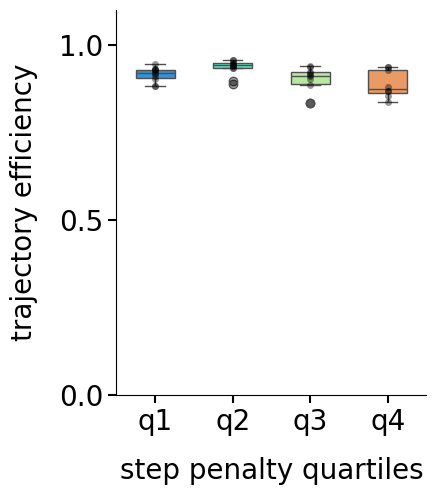

In [563]:
data = [q1_group, q2_group, q3_group, q4_group]

palette = sns.color_palette("rainbow", 4)

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)
plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)
plt.ylim(0,1.1)
plt.yticks(np.arange(0, 1.1, 0.5))
plt.ylabel("trajectory efficiency", fontsize=20, labelpad=15)
plt.yticks(fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

y_max = np.nanmax(means)
h = y_max * 0.05

# using pairwise_p dictionary from previous code
#add_sig_bar(ax, 0, 1, y_max + h,     h, pairwise_p["q1 vs q2"])
#add_sig_bar(ax, 1, 2, y_max + 3*h,   h, pairwise_p["q2 vs q3"])
#add_sig_bar(ax, 2, 3, y_max + 5*h,   h, pairwise_p["q3 vs q4"])

# optional wider comparisons
#add_sig_bar(ax, 0, 2, y_max + 7*h,   h, pairwise_p["q1 vs q3"])
#add_sig_bar(ax, 1, 3, y_max + 9*h,   h, pairwise_p["q2 vs q4"])
#add_sig_bar(ax, 0, 3, y_max + 11*h,  h, pairwise_p["q1 vs q4"])


sns.despine(top=True, right=True)

plt.show()

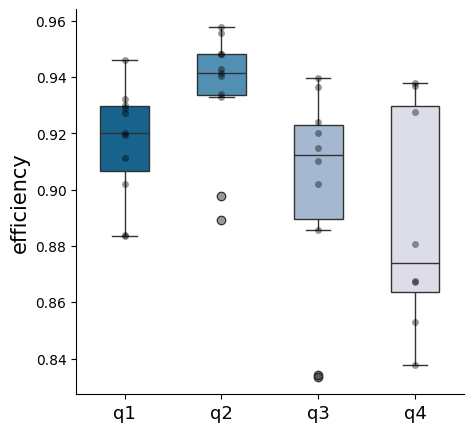

In [305]:
data = [q1_group, q2_group, q3_group, q4_group]

palette = sns.color_palette("PuBu_r", 4)

plt.figure(figsize=(5, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=13)
plt.ylabel("efficiency", fontsize=15)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(means)
h = y_max * 0.05

# using pairwise_p dictionary from previous code
#add_sig_bar(ax, 0, 1, y_max + h,     h, pairwise_p["q1 vs q2"])
#add_sig_bar(ax, 1, 2, y_max + 3*h,   h, pairwise_p["q2 vs q3"])
#add_sig_bar(ax, 2, 3, y_max + 5*h,   h, pairwise_p["q3 vs q4"])

# optional wider comparisons
#add_sig_bar(ax, 0, 2, y_max + 7*h,   h, pairwise_p["q1 vs q3"])
#add_sig_bar(ax, 1, 3, y_max + 9*h,   h, pairwise_p["q2 vs q4"])
#add_sig_bar(ax, 0, 3, y_max + 11*h,  h, pairwise_p["q1 vs q4"])

plt.show()

0.9632576476796375
0.009632576476796375


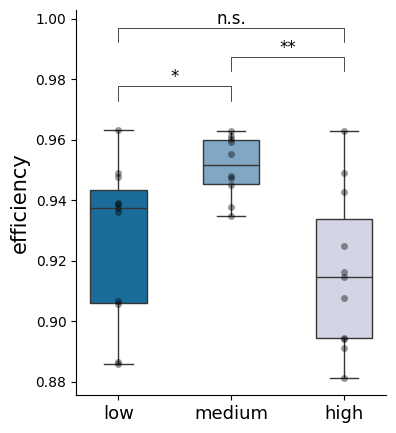

In [495]:
data = [low_group, mid_group, high_group]

palette = sns.color_palette("PuBu_r", 3)

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means (recommended)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks([0, 1, 2], ['low', 'medium', 'high'], fontsize=13)
plt.ylabel("efficiency", fontsize=15)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(means)
print(y_max)
h = y_max * 0.01
print(h)

add_sig_bar(ax, 0, 1, y_max + h, h/2, p_lm)
add_sig_bar(ax, 1, 2, y_max + 2*h, h/2, p_mh)
add_sig_bar(ax, 0, 2, y_max + 3*h, h/2, p_lh)

plt.show()

# Reaction time by step penalty

RT defined as
1) time from slice onset to trigger activation
2) time from when chosen wall becomes first visible to trigger activation


- extract time application
- get time or steps between slice onset and trigger activation events 

## episode length x step penalty

In [573]:
from data_extraction import extract_trial

In [593]:
mean_reaction_times_dict = {}
response_times_session = {}
response_steps_session = {}
direct_distances_session = {}
rt_dd_diff = {}

for session_id, trial_list in enumerate(trial_lists):
    #if session_id == 36:
        #continue

    reaction_times_trial = {}
    response_times = []
    response_steps = []

    for trial_index, trial in enumerate(trial_list):
        this_trial = extract_trial.extract_trial(trial=trial, trial_list=trial_list, trial_index=trial_index)

        slice_onset_event = this_trial[this_trial['eventDescription'] == globals.SLICE_ONSET]
        selected_trigger_event = this_trial[this_trial['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION]

        slice_onset_time = slice_onset_event['timeApplication'].iloc[0]
        selected_trigger_time = selected_trigger_event['timeApplication'].iloc[0]

        slice_idx = this_trial.index[this_trial['eventDescription'] == globals.SLICE_ONSET][0]
        trigger_idx = this_trial.index[this_trial['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION][0]

        reaction_time_seconds = selected_trigger_time - slice_onset_time
        rt_seconds = round(reaction_time_seconds.total_seconds(), 2)

        reaction_time_steps = trigger_idx - slice_idx


        reaction_times_trial[trial_index] = (rt_seconds, reaction_time_steps)
        response_times.append(rt_seconds)
        response_steps.append(reaction_time_steps)
    
    direct_dist = trajectory_efficiency.player_direct_distance_session(trial_list, player_index)
    
    direct_distances_session[session_id] = direct_dist
    response_times_session[session_id] = response_times
    response_steps_session[session_id] = response_steps
    #rt_dd_diff[session_id] = response_steps_session[session_id] - direct_distances_session[session_id]

    mean_reaction_time_seconds = np.mean([rt[0] for rt in reaction_times_trial.values()])
    mean_reaction_time_steps = np.mean([rt[1] for rt in reaction_times_trial.values()])

    mean_reaction_times_dict[session_id] = (mean_reaction_time_seconds, mean_reaction_time_steps)

In [594]:
# collect average reaction times for each session, sorted by step penalty
reaction_time_seconds = []
reaction_time_steps = []
rt_dd_differences = []
direct_distances = []
std_rt_list = []
sem_rt_list = []
sorted_penalties = []
sem_diff_list = []

for penalty, session_id in sorted(zip(step_penalties, mean_reaction_times_dict.keys()), key=lambda x: x[0]):
    #if session_id == 36:
        #continue
    reaction_time_seconds.append(mean_reaction_times_dict[session_id][0])
    reaction_time_steps.append(mean_reaction_times_dict[session_id][1])
    #rt_dd_differences.append(np.nanmean(rt_dd_diff[session_id]))
    direct_distances.append(np.nanmean(direct_distances_session[session_id]))

    std_rt_list.append(np.std(response_times_session[session_id]))
    sem_rt_list.append((np.std(response_times_session[session_id])) / np.sqrt(len(response_times_session[session_id])))
    
    #sem_diff_list.append((np.std(rt_dd_diff[session_id])) / np.sqrt(len(rt_dd_diff[session_id])))
        
    sorted_penalties.append(penalty)

without outliers

In [576]:
def remove_global_upper_iqr_outliers(data_dict, iqr_multiplier=1.5):
    """
    Removes upper-tail outliers using one global IQR threshold
    computed across all sessions/models.

    data_dict: {session_id: list/array of RTs}
    """

    # flatten all RTs across sessions
    all_values = np.concatenate([
        np.asarray(values, dtype=float)
        for values in data_dict.values()
    ])

    q1 = np.percentile(all_values, 5)
    qe = np.percentile(all_values, 95)
    iqr = qe - q1
    upper = qe + iqr_multiplier * iqr

    cleaned_dict = {}
    outliers_dict = {}

    for session_id, values in data_dict.items():
        values = np.asarray(values, dtype=float)

        cleaned_dict[session_id] = values[values <= upper]
        outliers_dict[session_id] = values[values > upper]

    return cleaned_dict, outliers_dict, upper

In [461]:
cleaned_response_times_session, global_outliers, global_upper_cutoff = (
    remove_global_upper_iqr_outliers(response_times_session)
)

print("Global upper cutoff:", global_upper_cutoff)

Global upper cutoff: 8.725


In [467]:
cleaned_response_times_session.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42])

In [469]:
cleaned_response_times_means = [np.nanmean(cleaned_response_times_session[session_id]) for session_id in cleaned_response_times_session.keys()]

In [443]:
max(reaction_time_seconds), min(reaction_time_seconds)

(np.float64(17.141113490364024), np.float64(1.7529954614220877))

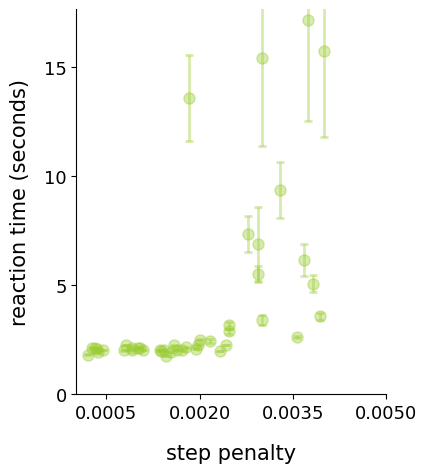

In [310]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    reaction_time_seconds,
    yerr=sem_rt_list,
    fmt='o',
    alpha=0.4,
    color="yellowgreen",
    markersize=8,

    ecolor='yellowgreen',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("reaction time (seconds)", fontsize=15, labelpad=10)
plt.ylim([0, max(reaction_time_seconds) + 0.5])
plt.yticks(np.arange(0, max(reaction_time_seconds) + 0.1, 5), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

In [564]:
rt_dd_differences

[np.float64(-16.96235142870522),
 np.float64(-16.61248847984332),
 np.float64(-16.53287884196169),
 np.float64(-16.589708595623343),
 np.float64(-16.544682371799944),
 np.float64(-16.549468713415717),
 np.float64(-16.63846806435831),
 np.float64(-16.57786261773952),
 np.float64(-16.552577151781982),
 np.float64(-16.582089744951215),
 np.float64(-16.618977777283696),
 np.float64(-16.599696236906304),
 np.float64(-16.506872907558606),
 np.float64(-16.52698509425837),
 np.float64(-16.907045620475362),
 np.float64(-16.45417200013908),
 np.float64(-16.530375209563037),
 np.float64(-16.732246191043373),
 np.float64(-16.460759247662118),
 np.float64(-18.010086943952242),
 np.float64(-17.569588176582247),
 np.float64(-16.622150404570228),
 np.float64(-17.175627811240417),
 np.float64(-16.105928350003097),
 np.float64(-11.233158817171226),
 np.float64(-10.29551496170785),
 np.float64(-12.321773624726076),
 np.float64(-4.6435475933694725),
 np.float64(-9.578247959942182),
 np.float64(-10.3814175

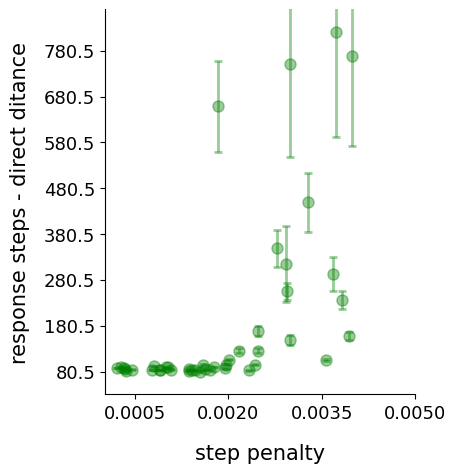

In [312]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_penalties,
    rt_dd_differences,
    yerr=sem_diff_list,
    fmt='o',
    alpha=0.4,
    color="green",
    markersize=8,

    ecolor='green',            
    elinewidth=2,              
    capsize=3,                 
    capthick=2,

    linestyle='none'
)

plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("response steps - direct ditance", fontsize=15, labelpad=10)
plt.ylim([min(rt_dd_differences) - 50, max(rt_dd_differences) + 50])
plt.yticks(np.arange(min(rt_dd_differences), max(rt_dd_differences), 100), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)

sns.despine(top=True, right=True)
plt.show()

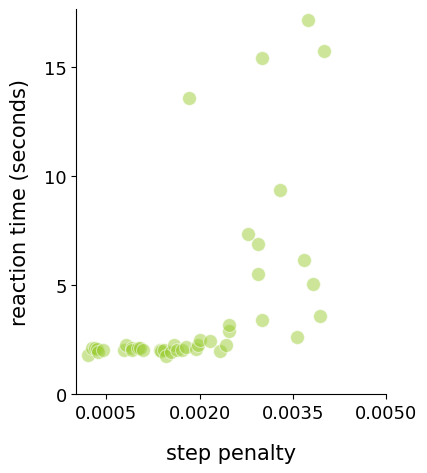

In [313]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=sorted_penalties, y=reaction_time_seconds, marker='o', alpha=0.5, color="yellowgreen", s=100)
plt.xlabel("step penalty", fontsize=15, labelpad=15)
plt.ylabel("reaction time (seconds)", fontsize=15, labelpad=10)
plt.ylim([0, max(reaction_time_seconds) + 0.5])
plt.yticks(np.arange(0, max(reaction_time_seconds) + 0.1, 5), fontsize=13)
plt.xticks(np.arange(0.0005, 0.005, 0.0015), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
#ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

### direct distances against RT coloured by group

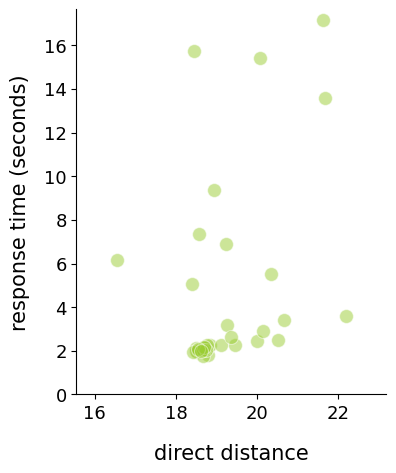

In [314]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=direct_distances, y=reaction_time_seconds, marker='o', alpha=0.5, color="yellowgreen", s=100)
plt.xlabel("direct distance", fontsize=15, labelpad=15)
plt.ylabel("response time (seconds)", fontsize=15, labelpad=10)
plt.ylim([0, max(reaction_time_seconds) + 0.5])
plt.yticks(np.arange(0, max(reaction_time_seconds) + 0.1, 2), fontsize=13)
plt.xlim([min(direct_distances) - 1, max(direct_distances) + 1])
plt.xticks(np.arange(16, max(direct_distances) + 1, 2), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
#ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

In [315]:
full_direct_distances = []
full_response_times = []
sorted_penalties = []

for penalty, session_id in sorted(zip(step_penalties, mean_reaction_times_dict.keys()), key=lambda x: x[0]):
    #if session_id == 31:
        #continue
    full_response_times.append(response_times_session[session_id])
    full_direct_distances.append(direct_distances_session[session_id])
    sorted_penalties.append(penalty)

In [316]:
mean_reaction_times_dict.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42])

In [339]:
len(full_direct_distances)

43

0.00034271867480129004
3


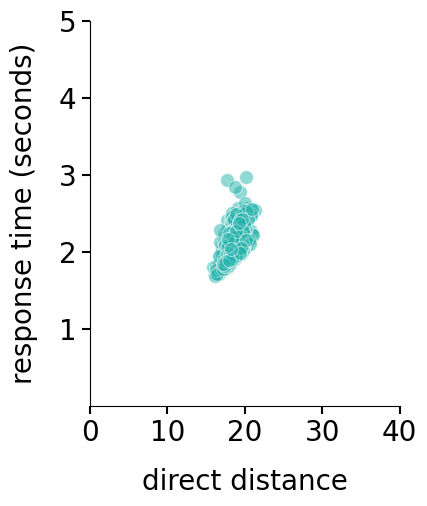

In [361]:
i = 3
print(sorted_penalties[i])
print(i)
plt.figure(figsize=(4, 5))

sns.scatterplot(
    x=full_direct_distances[i],
    y=full_response_times[i],
    marker='o',
    alpha=0.5,
    color="lightseagreen",
    s=100
)

plt.xlabel("direct distance", fontsize=20, labelpad=15)
plt.ylabel("response time (seconds)", fontsize=20, labelpad=15)

plt.ylim(0, 5) 
plt.xlim(0, 40)

plt.yticks(fontsize=20)
plt.xticks(np.arange(0, 41, 10), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.show()

0.00020832321024499834
0


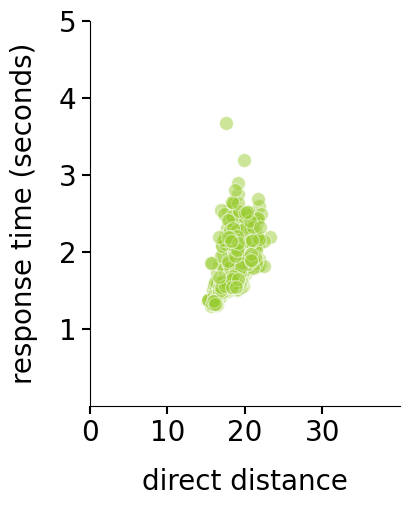

0.000268843665253371
1


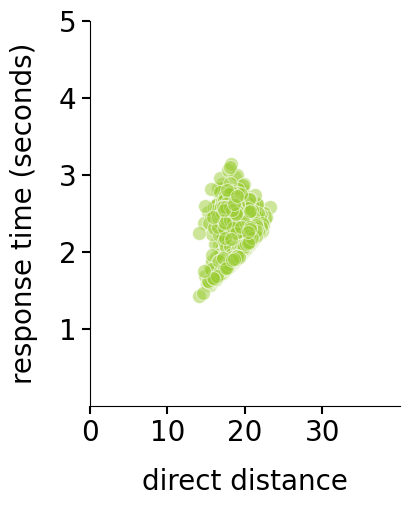

0.00032141641713678837
2


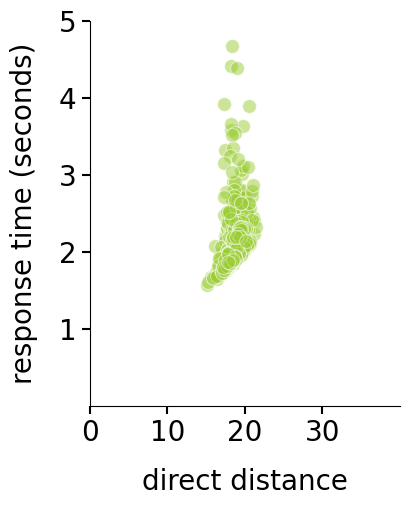

0.00034271867480129004
3


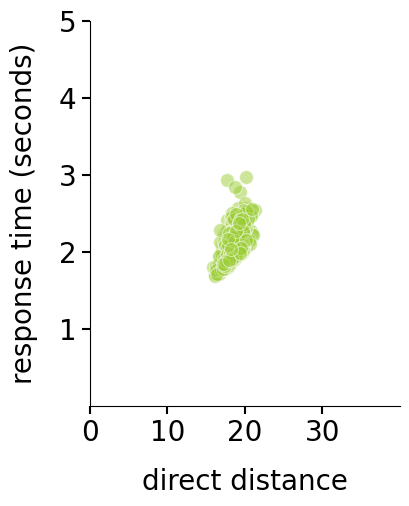

0.0003608045226428658
4


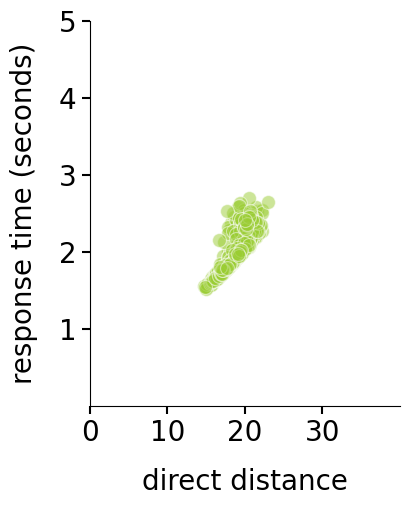

0.00044613672071136534
5


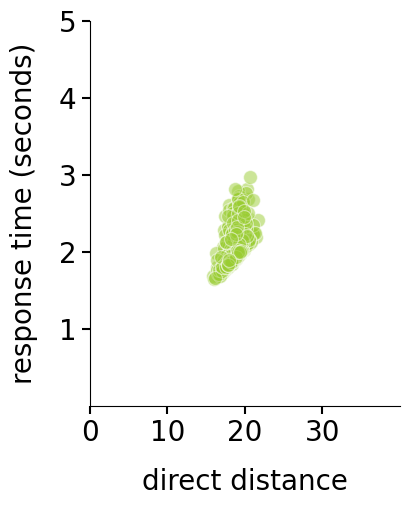

0.0007806486682966352
6


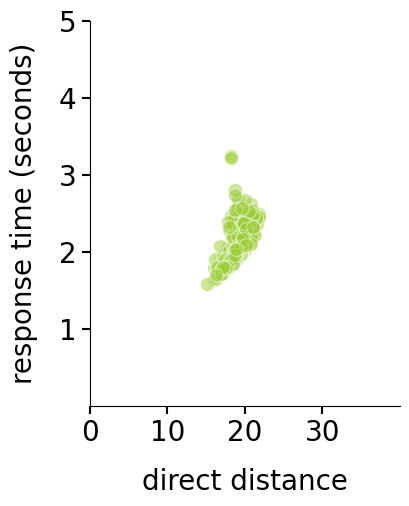

0.0008127213804982603
7


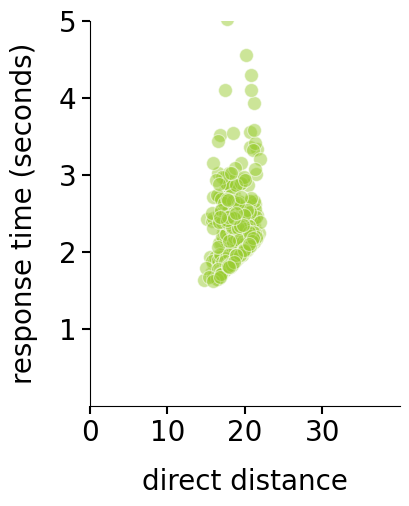

0.0009049233631230891
8


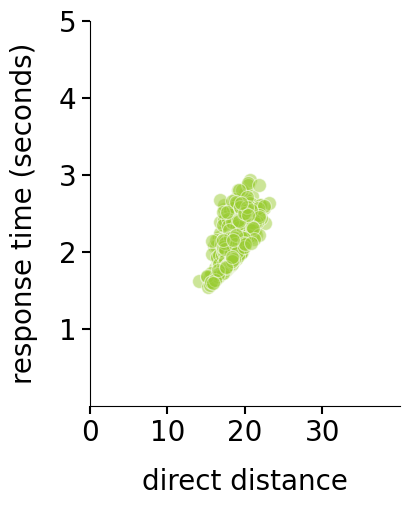

0.0009095777641050518
9


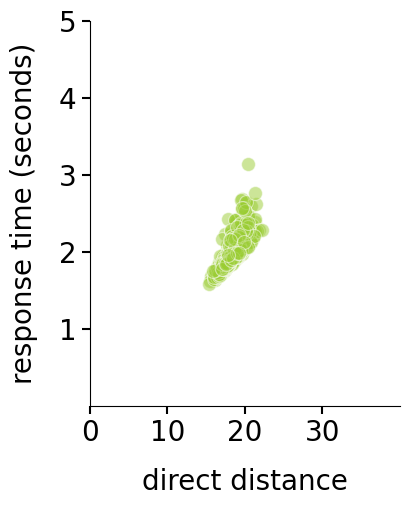

0.001002616947516799
10


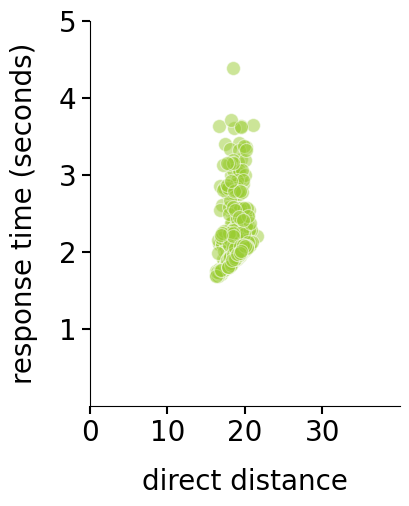

0.0010354247642681003
11


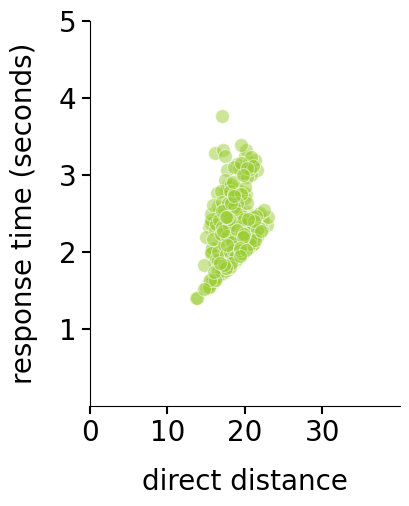

0.0010851738043129444
12


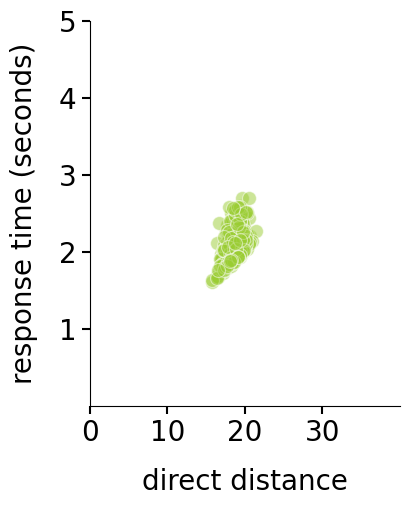

0.0013631514739245176
13


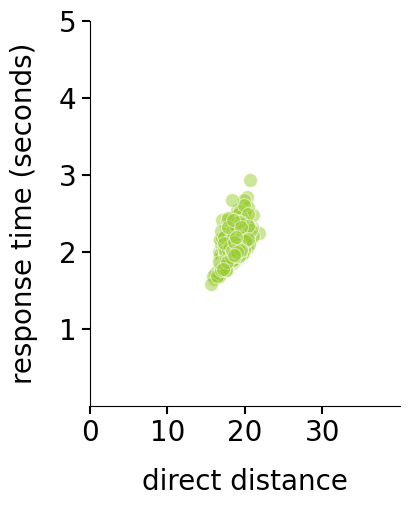

0.0013695930829271674
14


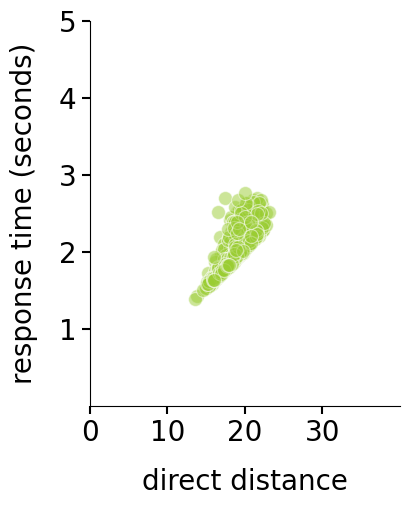

0.0014224493643268943
15


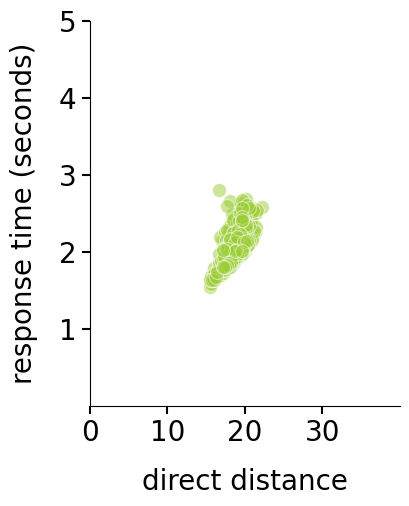

0.001460971194319427
16


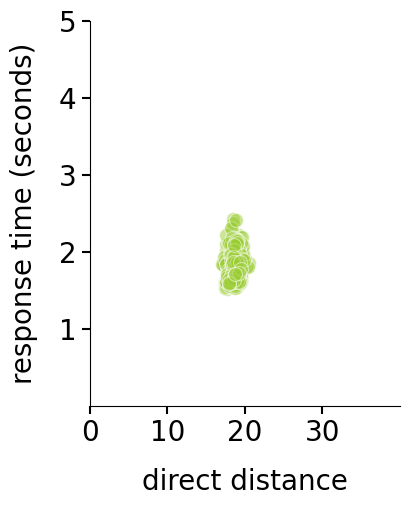

0.0015437181573361158
17


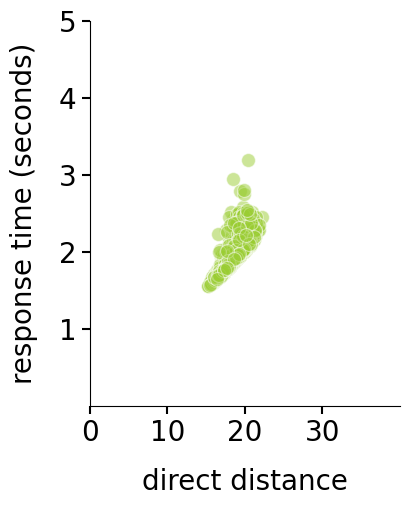

0.0015874444507062435
18


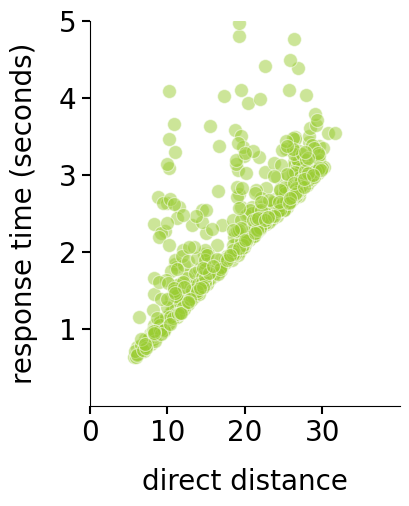

0.0016317025292664766
19


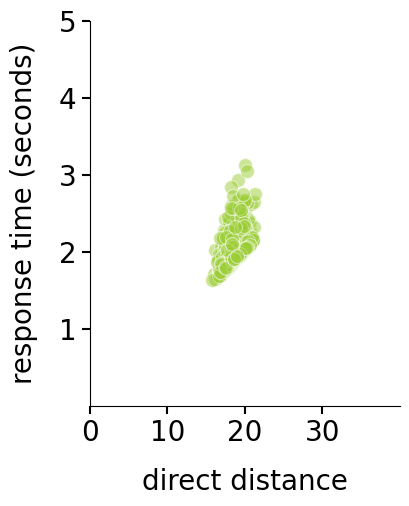

0.0017144576413556933
20


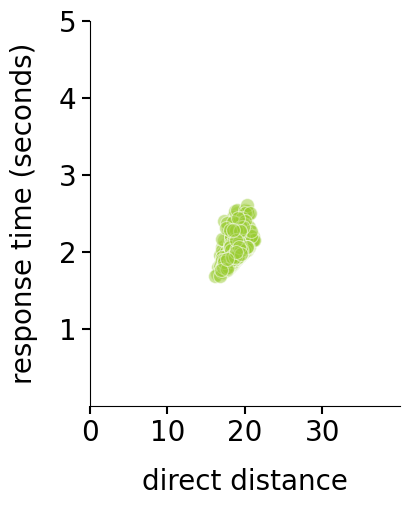

0.0017708404920995235
21


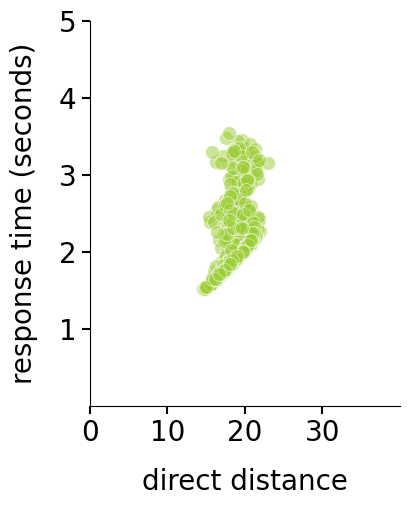

0.0018310054438188672
22


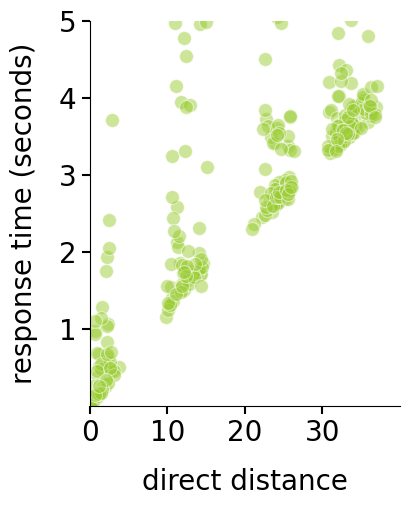

0.0019432592671364546
23


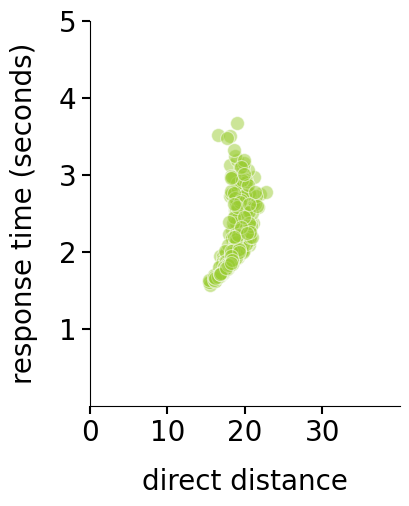

0.001966343028470874
24


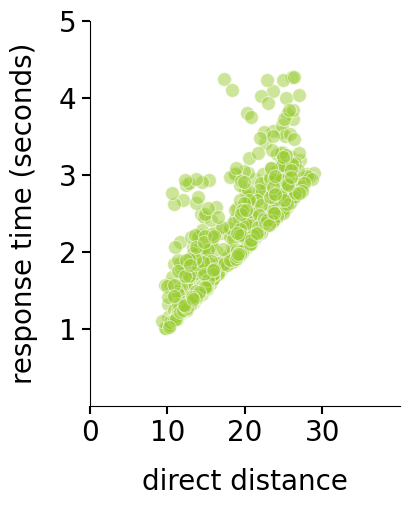

0.002004567300900817
25


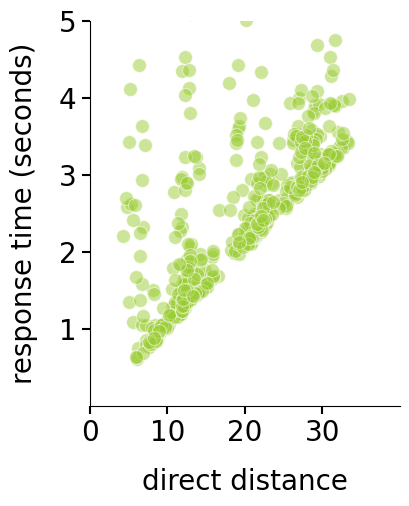

0.0021702854428440332
26


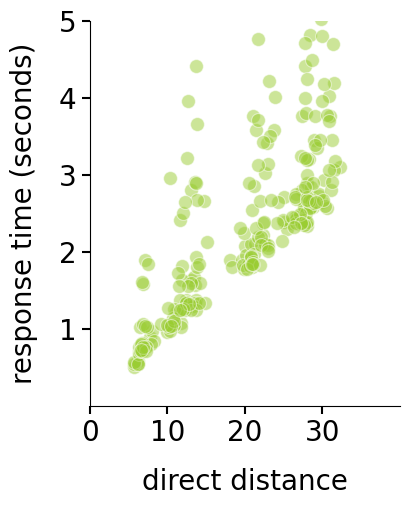

0.0023314235731959343
27


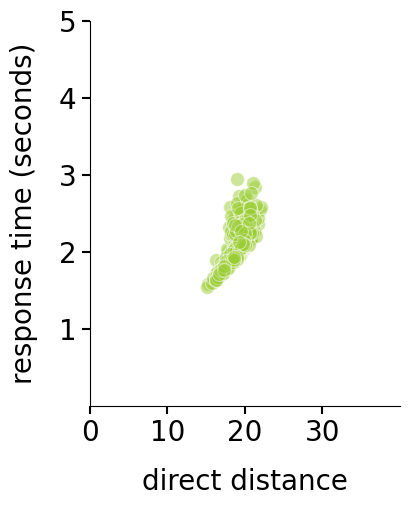

0.0024260496720671654
28


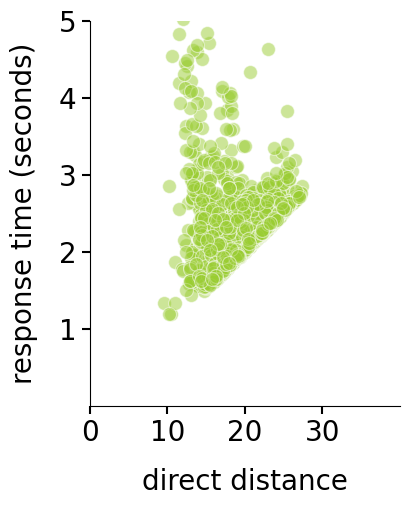

0.0024739333894103765
29


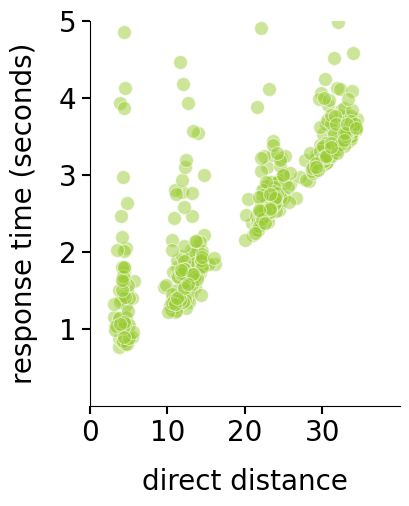

0.0024764309637248516
30


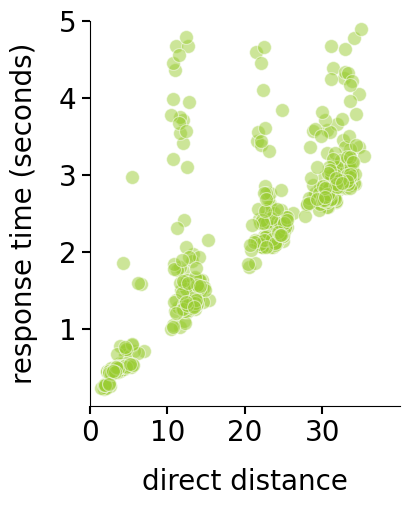

0.0027752178721129894
31


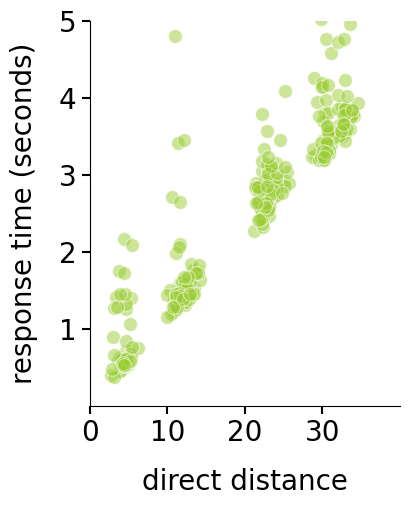

0.0029348323587328196
32


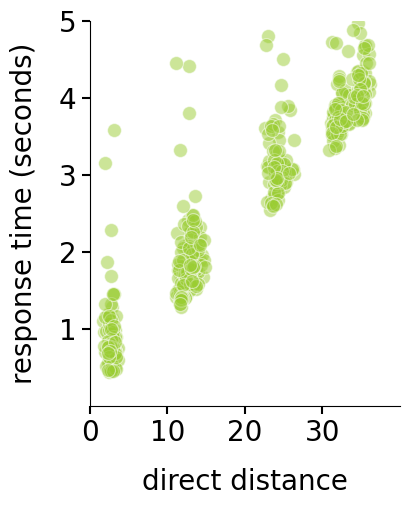

0.0029358896426856518
33


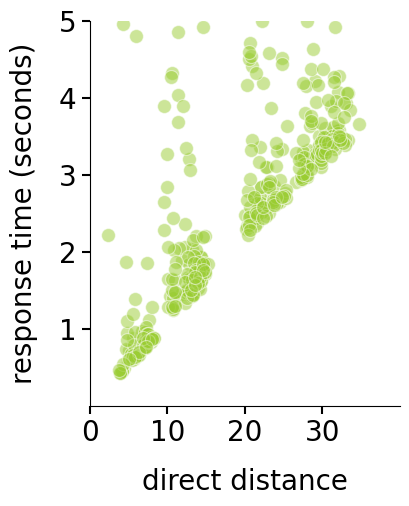

0.0029923466499894857
34


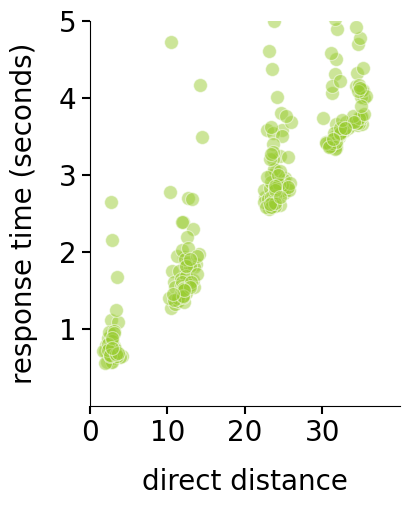

0.0029926744755357504
35


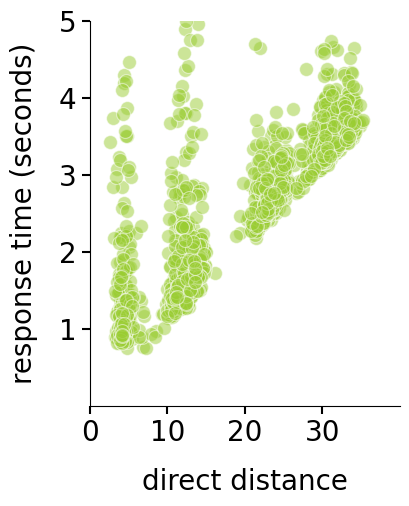

0.0032858503982424736
36


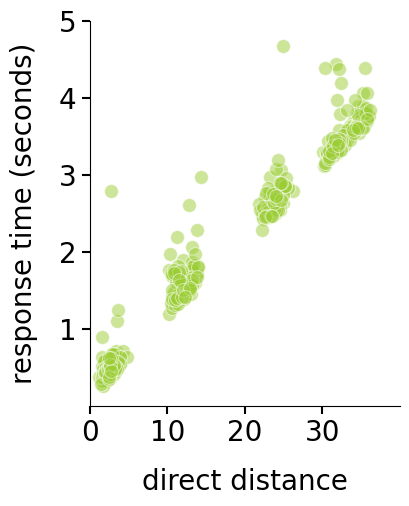

0.0035635593812912703
37


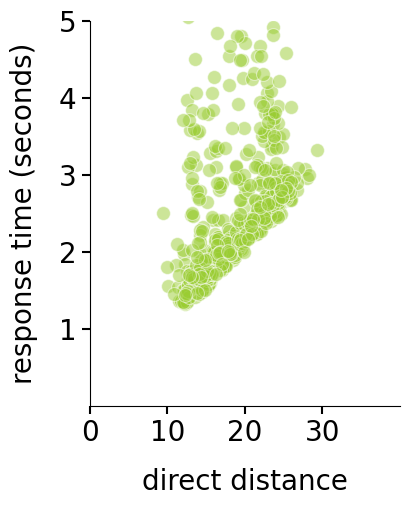

0.003680904395878315
38


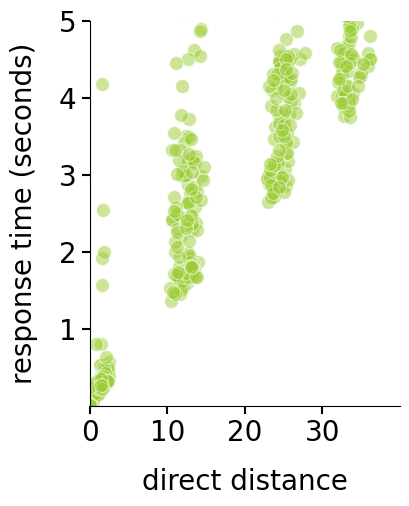

0.003736719489097595
39


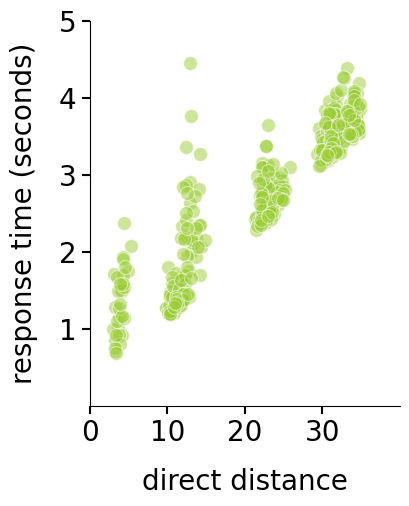

0.003820139216259122
40


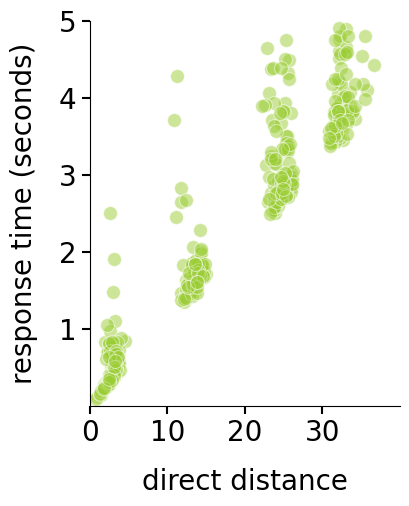

0.00393828796222806
41


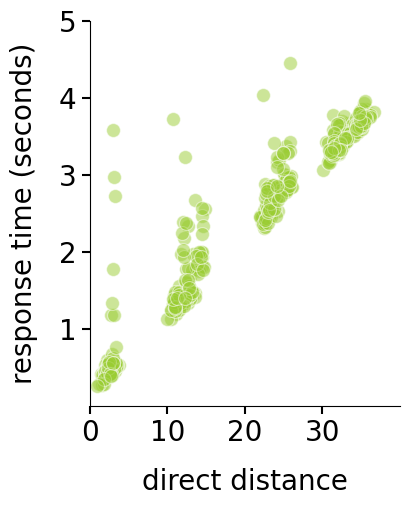

0.003991561476141214
42


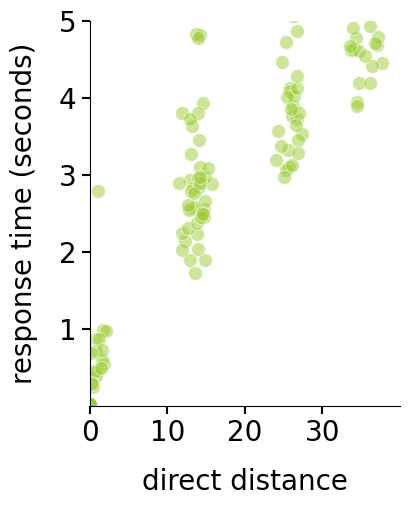

In [324]:
for i in range(len(full_direct_distances)):
    print(sorted_penalties[i])
    print(i)
    plt.figure(figsize=(4, 5))
    
    sns.scatterplot(
        x=full_direct_distances[i],
        y=full_response_times[i],
        marker='o',
        alpha=0.5,
        color="yellowgreen",
        s=100
    )

    plt.xlabel("direct distance", fontsize=20, labelpad=15)
    plt.ylabel("response time (seconds)", fontsize=20, labelpad=15)

    plt.ylim(0, 5) 
    plt.xlim(0, 40)

    plt.yticks(fontsize=20)
    plt.xticks(np.arange(0, 40, 10), fontsize=20)

    ax = plt.gca()
    ax.tick_params(width=1.5, length=6)
    plt.setp(ax.get_yticklabels()[0], visible=False)
    plt.setp(ax.get_yticklines()[0], visible=False)

    sns.despine(top=True, right=True)
    plt.show()

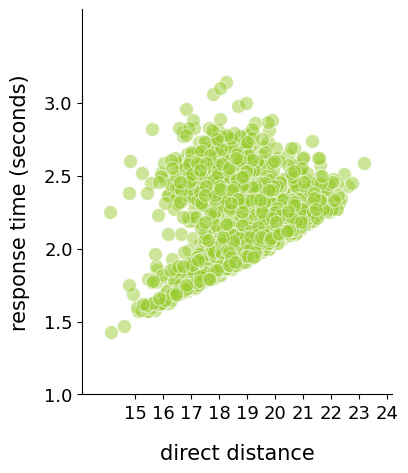

In [318]:
# scatter
plt.figure(figsize=(4, 5))
sns.scatterplot(x=full_direct_distances[1], y=full_response_times[1], marker='o', alpha=0.5, color="yellowgreen", s=100)
plt.xlabel("direct distance", fontsize=15, labelpad=15)
plt.ylabel("response time (seconds)", fontsize=15, labelpad=10)
plt.ylim([1, max(full_response_times[1]) + 0.5])
plt.yticks(np.arange(1, max(full_response_times[1]) + 0.1, 0.5), fontsize=13)
plt.xlim([min(full_direct_distances[1]) - 1, max(full_direct_distances[1]) + 1])
plt.xticks(np.arange(15, max(full_direct_distances[1]) + 1, 1), fontsize=13)
ax = plt.gca()
#ax.get_xticklabels()[0].set_visible(False)
#ax.get_yticklabels()[0].set_visible(False)
sns.despine(top=True, right=True)
plt.show()

In [341]:
from diptest import diptest

In [342]:
dip_stats = []
dip_pvals = []

for distances in full_direct_distances:
    dip, p = diptest(distances)
    dip_stats.append(dip)
    dip_pvals.append(p)

In [345]:
from sklearn.mixture import GaussianMixture

In [346]:
n_components_list = []

for distances in full_direct_distances:
    X = np.array(distances).reshape(-1,1)
    
    bics = []
    models = []
    
    for k in range(1, 6):  # test 1–5 bands
        gmm = GaussianMixture(n_components=k).fit(X)
        bics.append(gmm.bic(X))
        models.append(gmm)
    
    best_k = np.argmin(bics) + 1
    n_components_list.append(best_k)

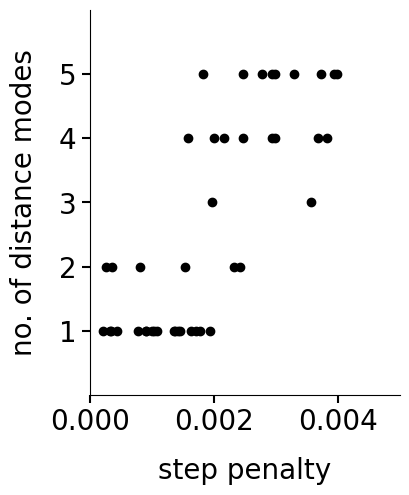

In [355]:
plt.figure(figsize=(4,5))

plt.scatter(sorted_penalties, n_components_list, color='black')

plt.xlabel("step penalty", fontsize=20, labelpad=15)
plt.ylabel("no. of distance modes", fontsize=20, labelpad=15)

plt.ylim(0, 6) 
plt.xlim(0, 0.005)

plt.xticks(np.arange(0, 0.0045, 0.002), fontsize=20)
plt.yticks(fontsize=20)
plt.yticks(np.arange(0, 6, 1), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.show()
plt.show()

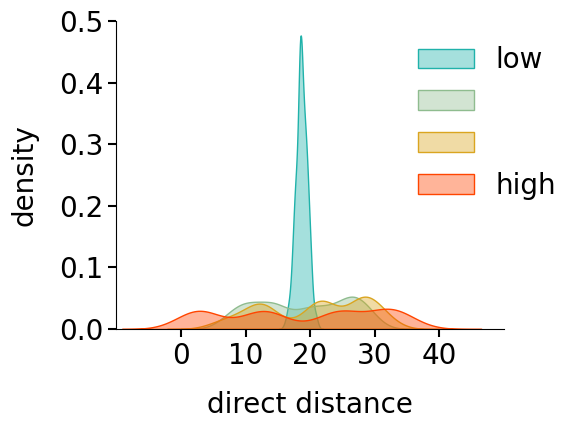

In [390]:
# example indices (replace with your actual ones)
low_i = 3
lowmid_i = 18
midhigh_i = 25
high_i = 40

plt.figure(figsize=(5,4))

sns.kdeplot(full_direct_distances[low_i], label='low', color='lightseagreen', fill=True, alpha=0.4)
sns.kdeplot(full_direct_distances[lowmid_i], label=' ', color='darkseagreen', fill=True, alpha=0.4)
sns.kdeplot(full_direct_distances[midhigh_i], label=' ',color='goldenrod', fill=True, alpha=0.4)
sns.kdeplot(full_direct_distances[high_i], label='high', color='orangered', fill=True, alpha=0.4)



plt.xlabel("direct distance", fontsize=20, labelpad=15)
plt.ylabel("density", fontsize=20, labelpad=15)

plt.ylim(0, 0.5) 
plt.xlim(-10, 50)

plt.xticks(np.arange(-10, 50, 10), fontsize=20)
plt.yticks(fontsize=20)
plt.yticks(np.arange(0, 0.6, 0.1), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)
plt.setp(ax.get_xticklabels()[0], visible=False)
plt.setp(ax.get_xticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), fontsize=20, frameon=False)
plt.show()

### box plots

In [595]:
penalties = np.array(sorted_penalties)
means = np.array(reaction_time_seconds)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

low_group = means[penalties <= low_thresh]
low_mid_group = means[(penalties > low_thresh) & (penalties <= mid_thresh)]
mid_high_group = means[(penalties > mid_thresh) & (penalties <= high_thresh)]
high_group = means[penalties > high_thresh]

In [596]:
data=[low_group, low_mid_group, mid_high_group, high_group]

In [597]:
# overall
stat, p = kruskal(low_group, low_mid_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise
p_llm = mannwhitneyu(low_group, low_mid_group).pvalue
p_lmmh = mannwhitneyu(low_mid_group, mid_high_group).pvalue
p_mhh = mannwhitneyu(mid_high_group, high_group).pvalue
p_lh = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 3.2740991203768495e-06


In [599]:
print(p_llm,p_lmmh,p_mhh,p_lh)

0.5114059218501164 0.0021899994345199467 0.00827421565071521 8.151536127743242e-05


0.8570556745182012


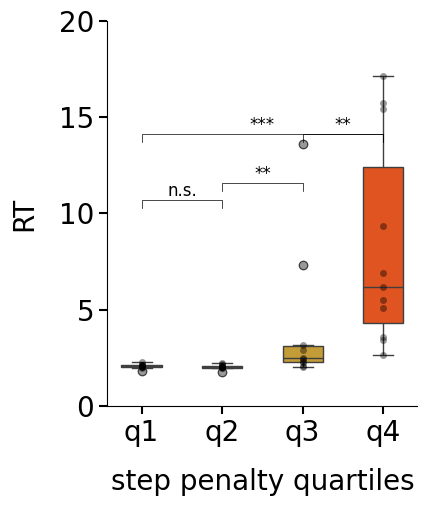

In [600]:
#data = [low_group, mid_group, high_group]
data = data

palette = ["lightseagreen", "darkseagreen", "goldenrod", "orangered"]

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means (recommended)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)
plt.ylim([0, 20])
plt.yticks(np.arange(0, 21, 5), fontsize=20)
plt.ylabel("RT", fontsize=20, labelpad=15)
plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)


ax = plt.gca()
ax.tick_params(width=1.5, length=6)


y_max = np.nanmax(means)
h = y_max * 0.05
print(h)

add_sig_bar(ax, 0, 1, y_max/2 + 2*h, h/2, p_llm)
add_sig_bar(ax, 1, 2, y_max/2 + 3*h, h/2, p_lmmh)
add_sig_bar(ax, 2, 3, y_max/2 + 6*h, h/2, p_mhh)
add_sig_bar(ax, 0, 3, y_max/2 + 6*h, h/2, p_lh)

sns.despine(top=True, right=True)

plt.show()

0.1404078947368421


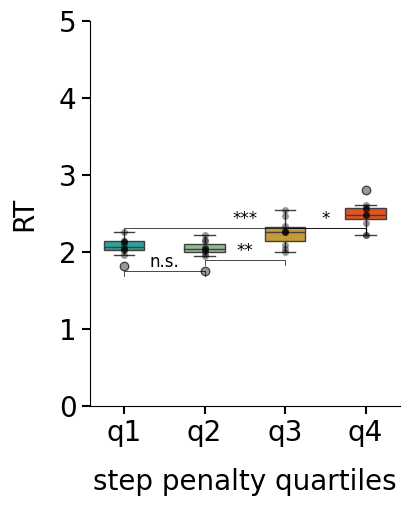

In [592]:
#data = [low_group, mid_group, high_group]
data = data

palette = ["lightseagreen", "darkseagreen", "goldenrod", "orangered"]

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means (recommended)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=20)
plt.ylim([0, 5])
plt.yticks(np.arange(0, 5.5, 1), fontsize=20)
plt.ylabel("RT", fontsize=20, labelpad=15)
plt.xlabel("step penalty quartiles", fontsize=20, labelpad=15)


ax = plt.gca()
ax.tick_params(width=1.5, length=6)


y_max = np.nanmax(means)
h = y_max * 0.05
print(h)

add_sig_bar(ax, 0, 1, y_max/2 + 2*h, h/2, p_llm)
add_sig_bar(ax, 1, 2, y_max/2 + 3*h, h/2, p_lmmh)
add_sig_bar(ax, 2, 3, y_max/2 + 6*h, h/2, p_mhh)
add_sig_bar(ax, 0, 3, y_max/2 + 6*h, h/2, p_lh)

sns.despine(top=True, right=True)

plt.show()

## response time is muddled by distances travelled

below we compute: 

excess time = RT − (optimal distance / nominal speed) 
    
- note that excess time can also include the time that the agents don't move at all

and run a regression on RT given distance and step penalty group


In [475]:
penalties = np.array(sorted_penalties)
means = np.array(rt_dd_differences)

low_thresh = np.percentile(penalties, 25)
mid_thresh = np.percentile(penalties, 50)
high_thresh = np.percentile(penalties, 75)

low_group = means[penalties <= low_thresh]
low_mid_group = means[(penalties > low_thresh) & (penalties <= mid_thresh)]
mid_high_group = means[(penalties > low_thresh) & (penalties <= mid_thresh)]
high_group = means[penalties > high_thresh]

In [476]:
data=[low_group, low_mid_group, mid_high_group, high_group]

In [477]:
# overall
stat, p = kruskal(low_group, low_mid_group, mid_high_group, high_group)
print("Kruskal-Wallis p =", p)

# pairwise
p_llm = mannwhitneyu(low_group, low_mid_group).pvalue
p_lmmh = mannwhitneyu(low_mid_group, mid_high_group).pvalue
p_mhh = mannwhitneyu(mid_high_group, high_group).pvalue
p_lh = mannwhitneyu(low_group, high_group).pvalue

Kruskal-Wallis p = 2.004387788129325e-05


41.04391373774302


/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_1176/3896305984.py:8: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=data, width=0.5, palette=palette)


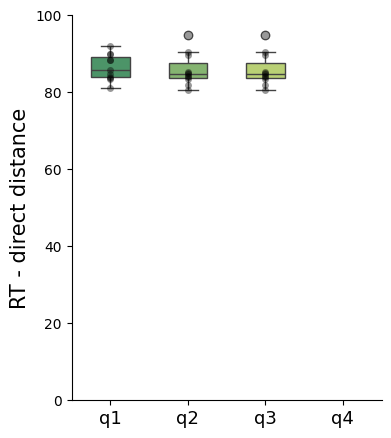

In [481]:
#data = [low_group, mid_group, high_group]
data = data

palette = sns.color_palette("summer", 3)

plt.figure(figsize=(4, 5))

sns.boxplot(data=data, width=0.5, palette=palette)

# overlay session means (recommended)
sns.stripplot(data=data, color='black', alpha=0.4, jitter=False)

plt.xticks([0, 1, 2, 3], ['q1', 'q2', 'q3', 'q4'], fontsize=13)
plt.ylabel("RT - direct distance", fontsize=15)
plt.ylim(0,100)

sns.despine(top=True, right=True)

ax = plt.gca()

y_max = np.nanmax(means)
h = y_max * 0.05
print(h)

#add_sig_bar(ax, 0, 1, y_max/2 + h, h/2, p_llm)
#add_sig_bar(ax, 1, 2, y_max/2 + 2*h, h/2, p_lmmh)
#add_sig_bar(ax, 2, 3, y_max/2 + 3*h, h/2, p_mhh)
#add_sig_bar(ax, 0, 3, y_max/2 + 6*h, h/2, p_lh)

plt.show()